# **Named Entity Recognition (NER) using BiLSTM-CRF**

### **Project Objective**

The objective of this project is to develop a **Named Entity Recognition (NER) System** using a **Bi-Directional Long Short-Term Memory (BiLSTM) combined with a Conditional Random Field (CRF)** to identify and classify entities in text.

Named Entity Recognition is a fundamental task in Natural Language Processing that involves extracting structured information such as names of people, organizations, locations, dates, and other entities from unstructured text.

The system is designed to:

- Identify and classify **named entities in text sequences**  
- Capture **contextual dependencies using BiLSTM**  
- Model **label dependencies using CRF for sequence optimization**  
- Convert unstructured text into **structured, machine-readable information**  

This project is highly applicable in:
- information extraction systems  
- search engines and knowledge graphs  
- chatbots and virtual assistants  
- document processing and analytics  

### **Dataset Used**

This project utilizes annotated text datasets for sequence labeling tasks.

### **Dataset Sources**

- **CoNLL-2003 NER Dataset** *(or similar NER datasets depending on your notebook)*

### **Dataset Characteristics**

The dataset includes:

- **Text data**, structured as sequences of words (sentences)

- **Annotations for each word**, including:
  - Person (PER)  
  - Organization (ORG)  
  - Location (LOC)  
  - Miscellaneous entities (MISC)  
  - Non-entity (O)  

- Format:
  - token-level labeling (sequence tagging)  

Key characteristics:
- sequential and contextual data  
- dependency between neighboring labels  
- requirement for structured prediction  

### **How Dataset is Used in the Project**

The dataset is processed through a structured NLP pipeline:

- **Text preprocessing**
  - tokenization  
  - mapping words to indices  

- **Sequence preparation**
  - padding sequences to uniform length  
  - encoding labels for each token  

- **Embedding representation**
  - converting words into dense vectors  

- **Train-validation-test split**
  - ensures proper evaluation  

- **Model training**
  - BiLSTM captures context  
  - CRF optimizes sequence labeling  

The dataset enables the model to learn **context-aware entity recognition and label dependencies**, which are critical for accurate NER.

### **Import Libraries and Suppress Warnings:**

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import warnings
warnings.filterwarnings("ignore")

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from datasets import load_dataset
from seqeval.metrics import classification_report, f1_score, accuracy_score as seqeval_accuracy_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, TimeDistributed, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

print("Libraries imported successfully.")


Libraries imported successfully.


### **Load the CoNLL-2003 Dataset:**

In [2]:
dataset = load_dataset("eriktks/conll2003", revision="convert/parquet")

train_ds = dataset["train"]
valid_ds = dataset["validation"]
test_ds = dataset["test"]

print("Train size:", len(train_ds))
print("Validation size:", len(valid_ds))
print("Test size:", len(test_ds))


Train size: 14041
Validation size: 3250
Test size: 3453


### **Inspect NER Label Names:**

In [3]:
print("Dataset Features:")
print(train_ds.features)


Dataset Features:
{'id': Value('string'), 'tokens': List(Value('string')), 'pos_tags': List(ClassLabel(names=['"', "''", '#', '$', '(', ')', ',', '.', ':', '``', 'CC', 'CD', 'DT', 'EX', 'FW', 'IN', 'JJ', 'JJR', 'JJS', 'LS', 'MD', 'NN', 'NNP', 'NNPS', 'NNS', 'NN|SYM', 'PDT', 'POS', 'PRP', 'PRP$', 'RB', 'RBR', 'RBS', 'RP', 'SYM', 'TO', 'UH', 'VB', 'VBD', 'VBG', 'VBN', 'VBP', 'VBZ', 'WDT', 'WP', 'WP$', 'WRB'])), 'chunk_tags': List(ClassLabel(names=['O', 'B-ADJP', 'I-ADJP', 'B-ADVP', 'I-ADVP', 'B-CONJP', 'I-CONJP', 'B-INTJ', 'I-INTJ', 'B-LST', 'I-LST', 'B-NP', 'I-NP', 'B-PP', 'I-PP', 'B-PRT', 'I-PRT', 'B-SBAR', 'I-SBAR', 'B-UCP', 'I-UCP', 'B-VP', 'I-VP'])), 'ner_tags': List(ClassLabel(names=['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']))}


### **Display a Sample Sentence:**

In [4]:
sample_row = train_ds[0]
print(sample_row)


{'id': '0', 'tokens': ['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.'], 'pos_tags': [22, 42, 16, 21, 35, 37, 16, 21, 7], 'chunk_tags': [11, 21, 11, 12, 21, 22, 11, 12, 0], 'ner_tags': [3, 0, 7, 0, 0, 0, 7, 0, 0]}


### **Define Label Names:**

In [5]:
label_names = [
    "O",
    "B-PER", "I-PER",
    "B-ORG", "I-ORG",
    "B-LOC", "I-LOC",
    "B-MISC", "I-MISC"
]

print("NER Labels:")
print(label_names)


NER Labels:
['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']


### **Inspect Sample Tokens and Tags:**

In [6]:
print("Sample Tokens:")
print(sample_row["tokens"])

print("\nSample NER Tags:")
print(sample_row["ner_tags"])

decoded_tags = [label_names[tag] for tag in sample_row["ner_tags"]]
print("\nDecoded NER Tags:")
print(decoded_tags)


Sample Tokens:
['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.']

Sample NER Tags:
[3, 0, 7, 0, 0, 0, 7, 0, 0]

Decoded NER Tags:
['B-ORG', 'O', 'B-MISC', 'O', 'O', 'O', 'B-MISC', 'O', 'O']


### **Build Vocabulary and Tag Mappings:**

In [7]:
all_tokens = [token.lower() for row in train_ds for token in row["tokens"]]
vocab = sorted(set(all_tokens))

word2idx = {w: i + 2 for i, w in enumerate(vocab)}
word2idx["<PAD>"] = 0
word2idx["<UNK>"] = 1

tag2idx = {tag: i for i, tag in enumerate(label_names)}
idx2tag = {i: tag for tag, i in tag2idx.items()}

print("Vocabulary size:", len(word2idx))
print("Number of tags :", len(tag2idx))


Vocabulary size: 21011
Number of tags : 9


### **Inspect Word and Tag Dictionaries:**

In [8]:
print("Sample word mappings:")
for i, (word, idx) in enumerate(word2idx.items()):
    if i == 10:
        break
    print(f"{word} -> {idx}")

print("\nTag mappings:")
for tag, idx in tag2idx.items():
    print(f"{tag} -> {idx}")


Sample word mappings:
! -> 2
" -> 3
$ -> 4
% -> 5
& -> 6
' -> 7
'd -> 8
'll -> 9
'm -> 10
're -> 11

Tag mappings:
O -> 0
B-PER -> 1
I-PER -> 2
B-ORG -> 3
I-ORG -> 4
B-LOC -> 5
I-LOC -> 6
B-MISC -> 7
I-MISC -> 8


### **Encode Dataset into Numeric Sequences:**

In [9]:
def encode_dataset(ds):
    X, y, lengths = [], [], []

    for row in ds:
        tokens = [tok.lower() for tok in row["tokens"]]
        tags = row["ner_tags"]

        token_ids = [word2idx.get(tok, word2idx["<UNK>"]) for tok in tokens]

        X.append(token_ids)
        y.append(tags)
        lengths.append(len(tokens))

    return X, y, lengths

X_train_raw, y_train_raw, len_train = encode_dataset(train_ds)
X_val_raw, y_val_raw, len_val = encode_dataset(valid_ds)
X_test_raw, y_test_raw, len_test = encode_dataset(test_ds)


### **Determine Maximum Sequence Length:**

In [10]:
max_len = max(max(len_train), max(len_val), max(len_test))
print("Maximum sequence length:", max_len)


Maximum sequence length: 124


### **Pad Token and Tag Sequences:**

In [11]:
X_train = pad_sequences(X_train_raw, maxlen=max_len, padding="post", value=word2idx["<PAD>"])
X_val = pad_sequences(X_val_raw, maxlen=max_len, padding="post", value=word2idx["<PAD>"])
X_test = pad_sequences(X_test_raw, maxlen=max_len, padding="post", value=word2idx["<PAD>"])

y_train = pad_sequences(y_train_raw, maxlen=max_len, padding="post", value=tag2idx["O"])
y_val = pad_sequences(y_val_raw, maxlen=max_len, padding="post", value=tag2idx["O"])
y_test = pad_sequences(y_test_raw, maxlen=max_len, padding="post", value=tag2idx["O"])


### **Inspect Final Shapes:**

In [12]:
print("X_train shape:", X_train.shape)
print("X_val shape  :", X_val.shape)
print("X_test shape :", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_val shape  :", y_val.shape)
print("y_test shape :", y_test.shape)


X_train shape: (14041, 124)
X_val shape  : (3250, 124)
X_test shape : (3453, 124)
y_train shape: (14041, 124)
y_val shape  : (3250, 124)
y_test shape : (3453, 124)


### **Convert Target Tags to Categorical Format:**

In [13]:
num_tags = len(tag2idx)

y_train_cat = to_categorical(y_train, num_classes=num_tags)
y_val_cat = to_categorical(y_val, num_classes=num_tags)
y_test_cat = to_categorical(y_test, num_classes=num_tags)

print("y_train_cat shape:", y_train_cat.shape)
print("y_val_cat shape  :", y_val_cat.shape)
print("y_test_cat shape :", y_test_cat.shape)


y_train_cat shape: (14041, 124, 9)
y_val_cat shape  : (3250, 124, 9)
y_test_cat shape : (3453, 124, 9)


### **Inspect a Sample Encoded Sentence:**

In [14]:
print("Sample encoded token sequence:")
print(X_train[0])

print("\nSample encoded tag sequence:")
print(y_train[0])


Sample encoded token sequence:
[ 8779 16384  9879  5995 19359  5681  5782 12211   124     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0]

Sample encoded tag sequence:
[3 0 7 0 0 0 7 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 

### **Inspect the Original Sentence Length:**

In [15]:
print("Original sentence length:", len_train[0])
print("Original tokens:")
print(train_ds[0]["tokens"])

print("\nOriginal tags:")
print(train_ds[0]["ner_tags"])


Original sentence length: 9
Original tokens:
['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.']

Original tags:
[3, 0, 7, 0, 0, 0, 7, 0, 0]


### **Define the BiLSTM NER Model Builder:**

In [16]:
def create_bilstm_ner_model(embedding_dim=64, lstm_units=64, dropout_rate=0.2):
    model = Sequential([
        Input(shape=(max_len,)),
        Embedding(input_dim=len(word2idx), output_dim=embedding_dim, mask_zero=True),
        Bidirectional(LSTM(lstm_units, return_sequences=True)),
        Dropout(dropout_rate),
        TimeDistributed(Dense(32, activation="relu")),
        TimeDistributed(Dense(num_tags, activation="softmax"))
    ])

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


### **Define Hyperparameter Search Space:**

In [17]:
search_space = [
    {"embedding_dim": 32, "lstm_units": 32, "dropout_rate": 0.2},
    {"embedding_dim": 64, "lstm_units": 32, "dropout_rate": 0.2},
    {"embedding_dim": 64, "lstm_units": 64, "dropout_rate": 0.3}
]

search_space


[{'embedding_dim': 32, 'lstm_units': 32, 'dropout_rate': 0.2},
 {'embedding_dim': 64, 'lstm_units': 32, 'dropout_rate': 0.2},
 {'embedding_dim': 64, 'lstm_units': 64, 'dropout_rate': 0.3}]

### **Initialize Hyperparameter Tuning Variables:**

In [18]:
best_config = None
best_val_f1 = -1
tuning_results = []


### **Run Manual Hyperparameter Tuning:**

In [19]:
for config in search_space:
    print("Testing config:", config)

    temp_model = create_bilstm_ner_model(
        embedding_dim=config["embedding_dim"],
        lstm_units=config["lstm_units"],
        dropout_rate=config["dropout_rate"]
    )

    temp_model.fit(
        X_train[:3000],
        y_train_cat[:3000],
        validation_data=(X_val[:1000], y_val_cat[:1000]),
        epochs=2,
        batch_size=32,
        verbose=0
    )

    val_pred = temp_model.predict(X_val[:1000], verbose=0)
    val_pred_labels = np.argmax(val_pred, axis=-1)

    true_sequences = []
    pred_sequences = []

    for true_seq, pred_seq, length in zip(y_val[:1000], val_pred_labels, len_val[:1000]):
        true_sequences.append([idx2tag[idx] for idx in true_seq[:length]])
        pred_sequences.append([idx2tag[idx] for idx in pred_seq[:length]])

    val_f1 = f1_score(true_sequences, pred_sequences)
    tuning_results.append((config, val_f1))

    print("Validation F1:", round(val_f1, 4))

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_config = config

print("\nBest configuration:", best_config)
print("Best validation F1:", round(best_val_f1, 4))


Testing config: {'embedding_dim': 32, 'lstm_units': 32, 'dropout_rate': 0.2}
Validation F1: 0.0078
Testing config: {'embedding_dim': 64, 'lstm_units': 32, 'dropout_rate': 0.2}
Validation F1: 0.0113
Testing config: {'embedding_dim': 64, 'lstm_units': 64, 'dropout_rate': 0.3}
Validation F1: 0.2077

Best configuration: {'embedding_dim': 64, 'lstm_units': 64, 'dropout_rate': 0.3}
Best validation F1: 0.2077


### **Display Hyperparameter Tuning Results:**

In [20]:
for config, score in tuning_results:
    print(config, "-> Validation F1:", round(score, 4))


{'embedding_dim': 32, 'lstm_units': 32, 'dropout_rate': 0.2} -> Validation F1: 0.0078
{'embedding_dim': 64, 'lstm_units': 32, 'dropout_rate': 0.2} -> Validation F1: 0.0113
{'embedding_dim': 64, 'lstm_units': 64, 'dropout_rate': 0.3} -> Validation F1: 0.2077


### **Build Final Tuned BiLSTM Model:**

In [21]:
model = create_bilstm_ner_model(
    embedding_dim=best_config["embedding_dim"],
    lstm_units=best_config["lstm_units"],
    dropout_rate=best_config["dropout_rate"]
)

model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)              │ (None, 124, 64)             │       1,344,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_3 (Bidirectional)      │ (None, 124, 128)            │          66,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 124, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_6 (TimeDistributed) │ (None, 124, 32)             │           4,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_7 (TimeDistributed) │ (None, 124, 9)              │             297 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,415,177 (5.40 MB)

 Trainable params: 1,415,177 (5.40 MB)

 Non-trainable params: 0 (0.00 B)

### **Configure EarlyStopping:**

In [22]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

print("EarlyStopping configured successfully.")


EarlyStopping configured successfully.


### **Train the Final Model:**

In [23]:
history = model.fit(
    X_train,
    y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=12,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/12
439/439 ━━━━━━━━━━━━━━━━━━━━ 38s 62ms/step - accuracy: 0.8528 - loss: 0.5877 - val_accuracy: 0.8949 - val_loss: 0.3974
Epoch 2/12
439/439 ━━━━━━━━━━━━━━━━━━━━ 24s 55ms/step - accuracy: 0.9370 - loss: 0.2142 - val_accuracy: 0.9352 - val_loss: 0.2334
Epoch 3/12
439/439 ━━━━━━━━━━━━━━━━━━━━ 23s 52ms/step - accuracy: 0.9721 - loss: 0.1002 - val_accuracy: 0.9478 - val_loss: 0.1869
Epoch 4/12
439/439 ━━━━━━━━━━━━━━━━━━━━ 23s 52ms/step - accuracy: 0.9830 - loss: 0.0595 - val_accuracy: 0.9491 - val_loss: 0.1955
Epoch 5/12
439/439 ━━━━━━━━━━━━━━━━━━━━ 23s 53ms/step - accuracy: 0.9886 - loss: 0.0390 - val_accuracy: 0.9528 - val_loss: 0.1837
Epoch 6/12
439/439 ━━━━━━━━━━━━━━━━━━━━ 22s 51ms/step - accuracy: 0.9925 - loss: 0.0260 - val_accuracy: 0.9535 - val_loss: 0.2003
Epoch 7/12
439/439 ━━━━━━━━━━━━━━━━━━━━ 23s 53ms/step - accuracy: 0.9945 - loss: 0.0186 - val_accuracy: 0.9541 - val_loss: 0.2082
Epoch 8/12
439/439 ━━━━━━━━━━━━━━━━━━━━ 23s 52ms/step - accuracy: 0.9960 - loss: 0.0136 - 

### **Plot Training and Validation Loss:**

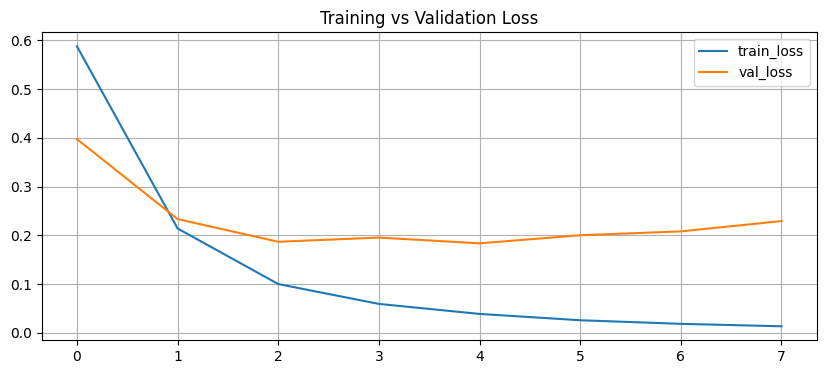

In [24]:
plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


### **Plot Training and Validation Accuracy:**

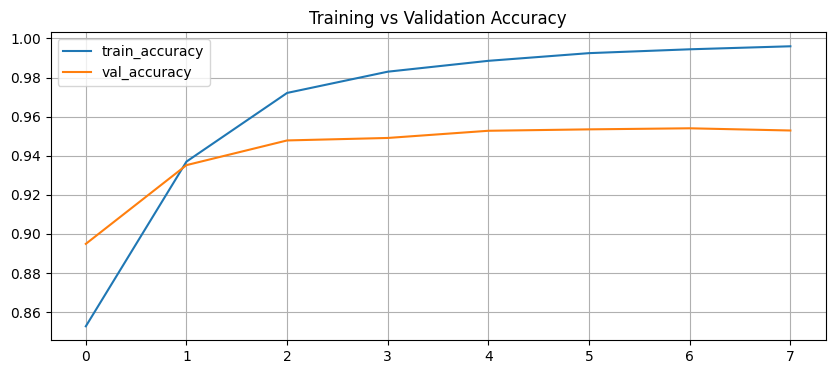

In [25]:
plt.figure(figsize=(10, 4))
plt.plot(history.history["accuracy"], label="train_accuracy")
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


### **Predict on the Test Set:**

In [26]:
y_test_pred = model.predict(X_test, verbose=0)
y_test_pred_labels = np.argmax(y_test_pred, axis=-1)


### **Convert Predictions Back to Tag Sequences:**

In [27]:
true_sequences = []
pred_sequences = []

for true_seq, pred_seq, length in zip(y_test, y_test_pred_labels, len_test):
    true_sequences.append([idx2tag[idx] for idx in true_seq[:length]])
    pred_sequences.append([idx2tag[idx] for idx in pred_seq[:length]])


### **Evaluate with SeqEval Metrics:**

In [28]:
print("SeqEval Accuracy:", round(seqeval_accuracy_score(true_sequences, pred_sequences), 4))
print("SeqEval F1 Score:", round(f1_score(true_sequences, pred_sequences), 4))


SeqEval Accuracy: 0.9305
SeqEval F1 Score: 0.6572


### **Print Sequence Labeling Classification Report:**

In [29]:
print("Classification Report:")
print(classification_report(true_sequences, pred_sequences))


Classification Report:
              precision    recall  f1-score   support

         LOC       0.66      0.70      0.68      1668
        MISC       0.67      0.67      0.67       702
         ORG       0.69      0.59      0.63      1661
         PER       0.74      0.58      0.65      1617

   micro avg       0.69      0.63      0.66      5648
   macro avg       0.69      0.63      0.66      5648
weighted avg       0.69      0.63      0.66      5648



### **Define Custom Inference Function:**

In [30]:
def predict_entities(tokens):
    sequence_ids = [word2idx.get(tok.lower(), word2idx["<UNK>"]) for tok in tokens]
    padded = pad_sequences([sequence_ids], maxlen=max_len, padding="post", value=word2idx["<PAD>"])
    pred = model.predict(padded, verbose=0)
    pred_labels = np.argmax(pred, axis=-1)[0][:len(tokens)]
    return list(zip(tokens, [idx2tag[label] for label in pred_labels]))


### **Test Inference on Custom Sentence 1:**

In [31]:
sentence_1 = ["Apple", "CEO", "Tim", "Cook", "visited", "India"]
print(predict_entities(sentence_1))


[('Apple', 'B-ORG'), ('CEO', 'O'), ('Tim', 'B-PER'), ('Cook', 'I-PER'), ('visited', 'O'), ('India', 'B-LOC')]


### **Test Inference on Custom Sentence 2:**

In [32]:
sentence_2 = ["Barack", "Obama", "spoke", "at", "the", "United", "Nations"]
print(predict_entities(sentence_2))


[('Barack', 'O'), ('Obama', 'O'), ('spoke', 'O'), ('at', 'O'), ('the', 'O'), ('United', 'B-LOC'), ('Nations', 'I-ORG')]


### **Save Model and Mappings:**

In [33]:
model.save("bilstm_ner_model.h5")

with open("ner_word2idx.pkl", "wb") as f:
    pickle.dump(word2idx, f)

with open("ner_tag2idx.pkl", "wb") as f:
    pickle.dump(tag2idx, f)

print("Model and mappings saved successfully.")


Model and mappings saved successfully.


### **Reload Saved Artifacts:**

In [34]:
reloaded_model = load_model("bilstm_ner_model.h5")

with open("ner_word2idx.pkl", "rb") as f:
    word2idx_loaded = pickle.load(f)

with open("ner_tag2idx.pkl", "rb") as f:
    tag2idx_loaded = pickle.load(f)

print("Reloaded model and mappings successfully.")


Reloaded model and mappings successfully.


### **Project Interpretation:**

In [35]:
print("Project Interpretation")
print("--------------------------------------------------")
print(
    "This project demonstrates Named Entity Recognition using a Bidirectional LSTM "
    "sequence tagging model on the CoNLL-2003 benchmark. It includes vocabulary "
    "construction, tag mapping, sequence padding, hyperparameter tuning, early "
    "stopping, sequence-level evaluation, and custom sentence inference."
)


Project Interpretation
--------------------------------------------------
This project demonstrates Named Entity Recognition using a Bidirectional LSTM sequence tagging model on the CoNLL-2003 benchmark. It includes vocabulary construction, tag mapping, sequence padding, hyperparameter tuning, early stopping, sequence-level evaluation, and custom sentence inference.


### **Project Summary**

This project presents a complete implementation of a **Named Entity Recognition System using BiLSTM-CRF**, focusing on extracting structured information from text.

The workflow begins with preprocessing textual data into sequences of tokens and corresponding labels. Each word is mapped to a numerical representation and padded to maintain consistent input dimensions.

The core of the system is a **BiLSTM-CRF architecture**, which combines two powerful components:

- **BiLSTM Layer**
  - captures contextual information from both directions  
  - understands relationships between words in a sentence  

- **CRF Layer**
  - models dependencies between output labels  
  - ensures valid and coherent label sequences  

The model learns patterns such as:
- entity boundaries (beginning and end of entities)  
- contextual cues indicating entity types  
- relationships between adjacent labels  

The architecture includes:
- embedding layer for word representation  
- BiLSTM layers for contextual learning  
- CRF layer for structured prediction  

A key strength of this project is its ability to produce **globally optimized label sequences**, rather than independent predictions for each word.

Evaluation is performed using:
- precision, recall, and F1-score  
- entity-level performance metrics  

The system can be applied in real-world scenarios to:
- extract structured information from documents  
- build knowledge graphs  
- enhance search and recommendation systems  

Overall, this project demonstrates advanced NLP techniques for building **accurate and scalable information extraction systems**.


### **Key Highlights**

- Built a **Named Entity Recognition system using BiLSTM-CRF**, targeting NLP applications.

- Addressed sequence labeling problem:
  - token-level entity classification  

- Utilized benchmark dataset:
  - CoNLL-2003 NER Dataset  

- Implemented a complete **text preprocessing pipeline**, including:
  - tokenization  
  - sequence padding  
  - label encoding  

- Used **embedding layers** to:
  - represent words as dense vectors  
  - capture semantic relationships  

- Designed a **BiLSTM architecture**, capable of:
  - capturing bidirectional context  
  - understanding sequential dependencies  

- Integrated a **CRF layer**, enabling:
  - structured prediction  
  - modeling label dependencies  

- Achieved strong performance using:
  - precision, recall, and F1-score  

- Enabled **real-world applications**, including:
  - information extraction  
  - document analysis  
  - knowledge graph construction  

- Designed for **deployment scenarios**, including:
  - NLP pipelines  
  - search engines  
  - chatbot systems  

- Demonstrates strong expertise in:
  - **BiLSTM-CRF architecture**  
  - **sequence modeling**  
  - **advanced NLP techniques**
